## RHF Orbital Energy Gradient

In [33]:
import numpy as np
from scipy.linalg import expm
from pyscf import gto, scf

In [34]:
mol1 = gto.M(
    atom='''
    N 0.000000 0.000000 0.000000
    N 0.000000 0.000000 1.3
    ''',
    basis='6-31G',
    unit='Angstrom',
    verbose=0
)

mf1 = scf.RHF(mol1)
mf1.max_cycle = 100
mf1.kernel()

mo_ref = mf1.mo_coeff.copy()

In [35]:
# Analytical gradient
nocc = np.sum(mf1.mo_occ > 0)
nvir = mf1.mo_coeff.shape[1] - nocc

grad_analytical = mf1.get_grad(mf1.mo_coeff, mf1.mo_occ)

# After couple of hours I figured out that gradients are stored as the nvir x nocc matrix not the
# nocc x nvir as I initially expected. So we need to reshape and transpose to get the expected shape.
grad_analytical = grad_analytical.reshape(nvir, nocc).T

In [36]:
np.set_printoptions(precision=8, suppress=True, linewidth=180)

def rotate_mos(mo_coeff, i, a, step):
    '''
    Rotate MOs by exponentiating an antisymmetric generator K.
    For a given occ and virtual orbital, and step size I will 
    have a rotation matrix which will update the mo_coeff.
    '''
    nmo = mo_coeff.shape[1]
    # Generating the antisymmetric generator K for the (i,a) pair
    kappa = np.zeros((nmo, nmo))
    kappa[i, a] = 1.0
    kappa[a, i] = -1.0
    U = expm(step * kappa)
    return mo_coeff @ U

def compute_energy_at_mo(mf, mo_rot):
    '''
    Given a rotated full MO coefficient matrix mo_rot, build the RHF density
    from the occupied columns and evaluate the HF total energy functional.
    '''
    mo_occ = mo_rot[:, np.where(mf.mo_occ > 0)[0]]
    dm = 2.0 * mo_occ @ mo_occ.T
    e_nuc = mf.mol.energy_nuc()
    return mf.energy_elec(dm=dm)[0] + e_nuc

def compute_grad_ia_numerical(mf, i, a, h):
    '''
    For a given occupied index iocc and virtual index avir, compute the orbital gradient using 
    central finite difference formula.
    '''
    mo0 = mo_ref.copy()
    
    # Rotate MOs in the (i,a) direction by +h and -h
    mo_p = rotate_mos(mo0, i, a, h)
    mo_m = rotate_mos(mo0, i, a, -h)

    # Compute energies at the rotated MOs
    e_p = compute_energy_at_mo(mf, mo_p)
    e_m = compute_energy_at_mo(mf, mo_m)

    # Central finite difference formula
    grad_ia = (e_p - e_m) / (2.0 * h)
    return grad_ia


def compute_grad_mat_step_sizes(mf, step_sizes):
    mo_occ = mf.mo_occ
    occidx = np.where(mo_occ > 0)[0]
    viridx = np.where(mo_occ == 0)[0]
    nocc = len(occidx)
    nvir = len(viridx)
    grad_mat = {}


    def get_grad_mat(h):
        G = np.zeros((nocc, nvir))
        for i_idx, iocc in enumerate(occidx):
            for a_idx, avir in enumerate(viridx):
                g_fd = compute_grad_ia_numerical(mf, iocc, avir, h)
                G[i_idx, a_idx] = g_fd
        return G
    
    for h in step_sizes:
        grad_mat[h] = get_grad_mat(h)
    
    return grad_mat

In [37]:
# It's time to run and compare.

# Some sanity prints
occidx = np.where(mf1.mo_occ > 0)[0]
viridx = np.where(mf1.mo_occ == 0)[0]
nocc = len(occidx)
nvir = len(viridx)

print(f"nmo  = {mf1.mo_coeff.shape[1]}")
print(f"nocc = {nocc}")
print(f"nvir = {nvir}")

print(f"Analytic gradient matrix:", grad_analytical.shape)

# Using finite difference compute the orbital gradient matrix for different step sizes
step_sizes = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
grad_mat_fd = compute_grad_mat_step_sizes(mf1, step_sizes)

errors_metrics = {}
for h in step_sizes:
    grad_num = grad_mat_fd[h]
    mae = np.mean(np.abs(grad_num - grad_analytical))
    rmse = np.sqrt(np.mean((grad_num - grad_analytical)**2))
    frobenius_norm = np.linalg.norm(grad_num - grad_analytical)
    max_abs_error = np.max(np.abs(grad_num - grad_analytical))
    errors_metrics[h] = {
        "mae": mae,
        "rmse": rmse,
        "frobenius_norm": frobenius_norm,
        "max_abs_error": max_abs_error,
    }


nmo  = 18
nocc = 7
nvir = 11
Analytic gradient matrix: (7, 11)


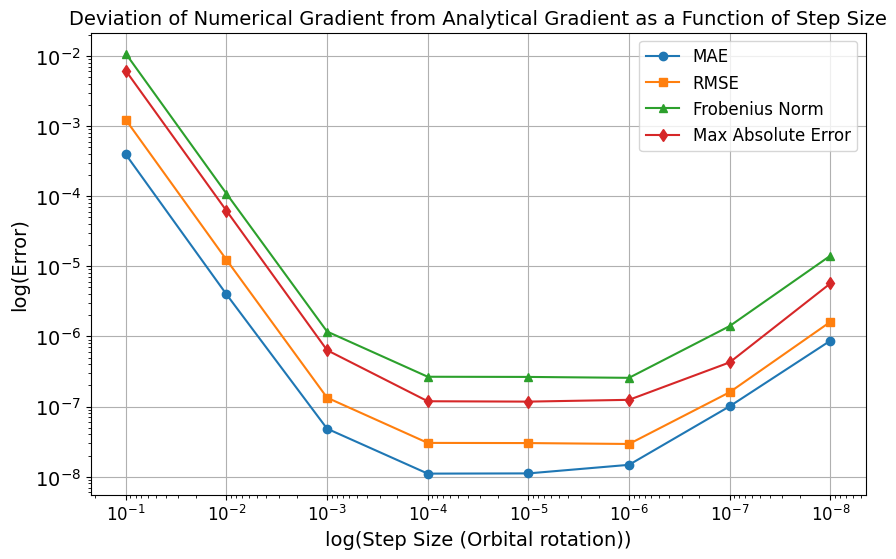

In [38]:
# Plotting the errors vs step size
import matplotlib.pyplot as plt

h_values = np.array(step_sizes)
mae_values = [errors_metrics[h]["mae"] for h in step_sizes]
rmse_values = [errors_metrics[h]["rmse"] for h in step_sizes]
frobenius_values = [errors_metrics[h]["frobenius_norm"] for h in step_sizes]
max_abs_error_values = [errors_metrics[h]["max_abs_error"] for h in step_sizes]

plt.figure(figsize=(10, 6))
plt.loglog(h_values, mae_values, marker='o', label='MAE')
plt.loglog(h_values, rmse_values, marker='s', label='RMSE')
plt.loglog(h_values, frobenius_values, marker='^', label='Frobenius Norm')
plt.loglog(h_values, max_abs_error_values, marker='d', label='Max Absolute Error')
plt.gca().invert_xaxis()
plt.xlabel('log(Step Size (Orbital rotation))', fontsize=14)
plt.ylabel('log(Error)', fontsize=14)
plt.title('Deviation of Numerical Gradient from Analytical Gradient as a Function of Step Size', fontsize=14)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.grid(True)
plt.show()


## MC-SCF Orbital Gradient Benchmark: (Numerical vs Analytical)

In [39]:
import numpy as np
from scipy.linalg import expm
from pyscf import gto, mcscf, scf
from pyscf.csf_fci import csf_solver

In [40]:
np.set_printoptions(precision=8, suppress=True, linewidth=180)

def rotate_mos(mo_coeff, p, q, step):
    '''
    Rotate MOs by exponentiating an antisymmetric generator K.
    For a given orbital pair (p,q), build the rotation matrix and update mo_coeff.
    '''
    nmo = mo_coeff.shape[1]
    kappa = np.zeros((nmo, nmo), dtype=mo_coeff.dtype)
    kappa[p, q] = 1.0
    kappa[q, p] = -1.0
    U = expm(step * kappa)
    return mo_coeff @ U


def compute_mcscf_energy_at_mo(mc_ref, mo_rot):
    '''
    Evaluate the CASSCF energy at a rotated MO coefficient matrix mo_rot.

    A fresh CASSCF object is built with the same active space, but with
    macro orbital optimization disabled, so this acts as an energy evaluation
    at fixed rotated orbitals.
    '''
    ncas = mc_ref.ncas
    nelecas = mc_ref.nelecas
    mf = mc_ref._scf

    mc_temp = mcscf.CASCI(mf, ncas, nelecas)
    mc_temp.fcisolver = csf_solver(mol, smult=1)
    energy = mc_temp.kernel(mo_rot)[0]
    assert mc_temp.converged
    return energy


def compute_grad_pq_numerical(mc, p, q, h):
    '''
    For a given orbital pair (p,q), compute the orbital gradient using
    the central finite-difference formula.
    '''
    mo0 = mc.mo_coeff.copy()

    mo_p = rotate_mos(mo0, p, q, +h)
    mo_m = rotate_mos(mo0, p, q, -h)

    e_p = compute_mcscf_energy_at_mo(mc, mo_p)
    e_m = compute_mcscf_energy_at_mo(mc, mo_m)

    grad_pq = (e_p - e_m) / (2.0 * h)
    return grad_pq

In [41]:
def compute_mcscf_grad_blocks_step_sizes(mc, step_sizes):
    '''
    Compute numerical CASSCF orbital-gradient blocks for several step sizes.

    Returns a dictionary keyed by step size h, where each value contains:
      - core_active : shape (ncore, nact)
      - active_vir  : shape (nact, nvir)
      - core_vir    : shape (ncore, nvir)
      - packed      : flat vector in the same block order:
                      [core-active, active-vir, core-vir]
    '''
    ncore = mc.ncore
    nact = mc.ncas
    nmo = mc.mo_coeff.shape[1]
    nvir = nmo - ncore - nact

    core_idx = np.arange(0, ncore)
    act_idx  = np.arange(ncore, ncore + nact)
    vir_idx  = np.arange(ncore + nact, nmo)

    grad_blocks = {}

    def get_grad_blocks(h):
        G_ca = np.zeros((ncore, nact))
        G_av = np.zeros((nact, nvir))
        G_cv = np.zeros((ncore, nvir))

        packed = []

        # core-active block
        for i_core, p in enumerate(core_idx):
            for i_act, q in enumerate(act_idx):
                g_fd = compute_grad_pq_numerical(mc, p, q, h)
                G_ca[i_core, i_act] = g_fd
                packed.append(g_fd)

        # active-virtual block
        for i_act, p in enumerate(act_idx):
            for i_vir, q in enumerate(vir_idx):
                g_fd = compute_grad_pq_numerical(mc, p, q, h)
                G_av[i_act, i_vir] = g_fd
                packed.append(g_fd)

        # core-virtual block
        for i_core, p in enumerate(core_idx):
            for i_vir, q in enumerate(vir_idx):
                g_fd = compute_grad_pq_numerical(mc, p, q, h)
                G_cv[i_core, i_vir] = g_fd
                packed.append(g_fd)

        return {
            "core_active": G_ca,
            "active_vir": G_av,
            "core_vir": G_cv,
            "packed": np.array(packed)
        }

    for h in step_sizes:
        print("Computing the numerical grad for step size", h)
        grad_blocks[h] = get_grad_blocks(h)

    return grad_blocks


def unpack_mcscf_grad_analytical(mc, grad_analytical):
    '''
    Unpack the analytical CASSCF gradient vector into the three orbital blocks
    using the block order:
        [core-active, active-vir, core-vir]
    '''
    ncore = mc.ncore
    nact = mc.ncas
    nmo = mc.mo_coeff.shape[1]
    nvir = nmo - ncore - nact

    n_ca = ncore * nact
    n_av = nact * nvir
    n_cv = ncore * nvir

    assert len(grad_analytical) == n_ca + n_av + n_cv, \
        f"Gradient length mismatch: got {len(grad_analytical)}, expected {n_ca+n_av+n_cv}"

    idx = 0

    G_ca = grad_analytical[idx:idx+n_ca].reshape(ncore, nact)
    idx += n_ca

    G_av = grad_analytical[idx:idx+n_av].reshape(nact, nvir)
    idx += n_av

    G_cv = grad_analytical[idx:idx+n_cv].reshape(ncore, nvir)
    idx += n_cv

    return {
        "core_active": G_ca,
        "active_vir": G_av,
        "core_vir": G_cv
    }

In [42]:
def compare_mcscf_gradients(mc, grad_analytical, step_sizes, verbose=True):
    grad_num = compute_mcscf_grad_blocks_step_sizes(mc, step_sizes)
    grad_an  = unpack_mcscf_grad_analytical(mc, grad_analytical)

    data = {
        "step_sizes": list(step_sizes),
        "core_active": {
            "MAE": [],
            "RMSE": [],
            "Frobenius Norm": [],
            "Max Abs Error": [],
        },
        "active_vir": {
            "MAE": [],
            "RMSE": [],
            "Frobenius Norm": [],
            "Max Abs Error": [],
        },
        "core_vir": {
            "MAE": [],
            "RMSE": [],
            "Frobenius Norm": [],
            "Max Abs Error": [],
        }
    }

    for h in step_sizes:
        if verbose:
            print(f"\n========== Step size h = {h:.1e} ==========")

        for block_name in ["core_active", "active_vir", "core_vir"]:
            Gnum = grad_num[h][block_name]
            Gan  = grad_an[block_name]
            diff = Gnum - Gan

            mae = np.mean(np.abs(diff))
            rmse = np.sqrt(np.mean(diff**2))
            frob = np.linalg.norm(diff)
            if diff.size > 0:
                max_abs = np.max(np.abs(diff))
            else:
                max_abs = 0
            data[block_name]["MAE"].append(mae)
            data[block_name]["RMSE"].append(rmse)
            data[block_name]["Frobenius Norm"].append(frob)
            data[block_name]["Max Abs Error"].append(max_abs)

            if verbose:
                print(f"\n--- Block: {block_name} ---")
                print("\nError metrics:")
                print("MAE            =", mae)
                print("RMSE           =", rmse)
                print("Frobenius norm =", frob)
                print("Max abs error  =", max_abs)

    return data

In [43]:
# for basis in ['STO-6G', '6-31G', 'CC-PVDZ']:
#     mol = gto.M(
#         atom='''
#         Be 0 0 0
#         H 0 0 -1.5
#         H 0 0 1.5
#         ''',
#         basis=basis,
#         unit='Angstrom',
#         max_memory=100000,
#         verbose=0
#     )

#     mf = scf.RHF(mol)
#     mf.max_cycle = 100
#     mf.kernel()

#     mc = mcscf.CASSCF(mf, 6, 4)
#     mc.fcisolver = csf_solver(mol, smult=1)
#     mc.conv_tol = 1e-8
#     mc.kernel()

#     print("CASSCF converged?", mc.converged)

#     # Analytical gradient:
#     grad_analytical = mc.get_grad()
#     print("gradient-shape:", grad_analytical.shape)

#     step_sizes = [5e-1, 1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 1e-4]
#     data = compare_mcscf_gradients(mc, grad_analytical, step_sizes)

#     import json

#     with open(f'beh2.{basis}.json', 'w') as f:
#         json.dump(data, f, indent=2)

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import json

BeH2_CC-PVDZ_core_active_grouped_bar.pdf
BeH2_CC-PVDZ_active_vir_grouped_bar.pdf
BeH2_CC-PVDZ_core_vir_grouped_bar.pdf


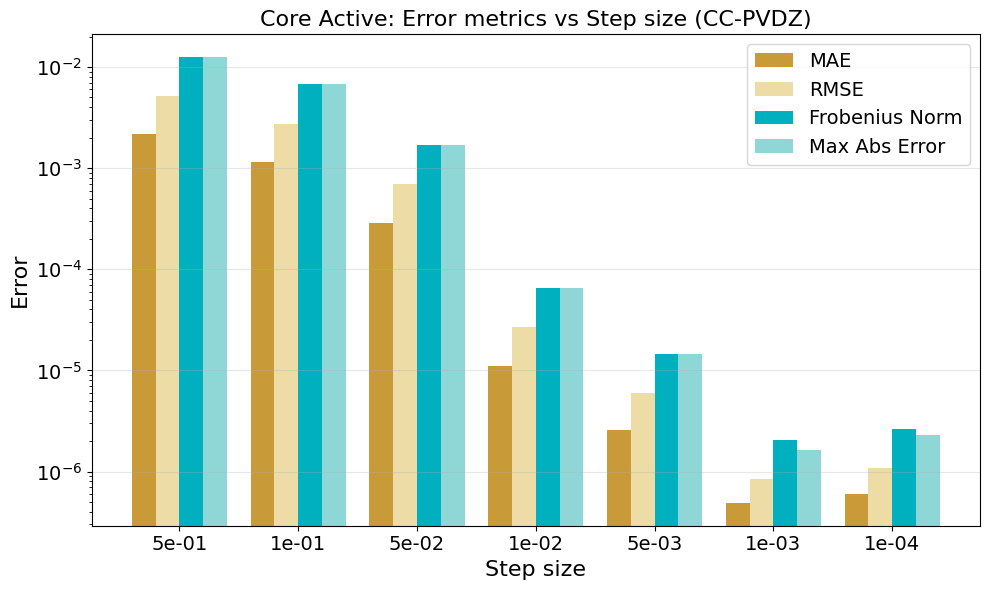

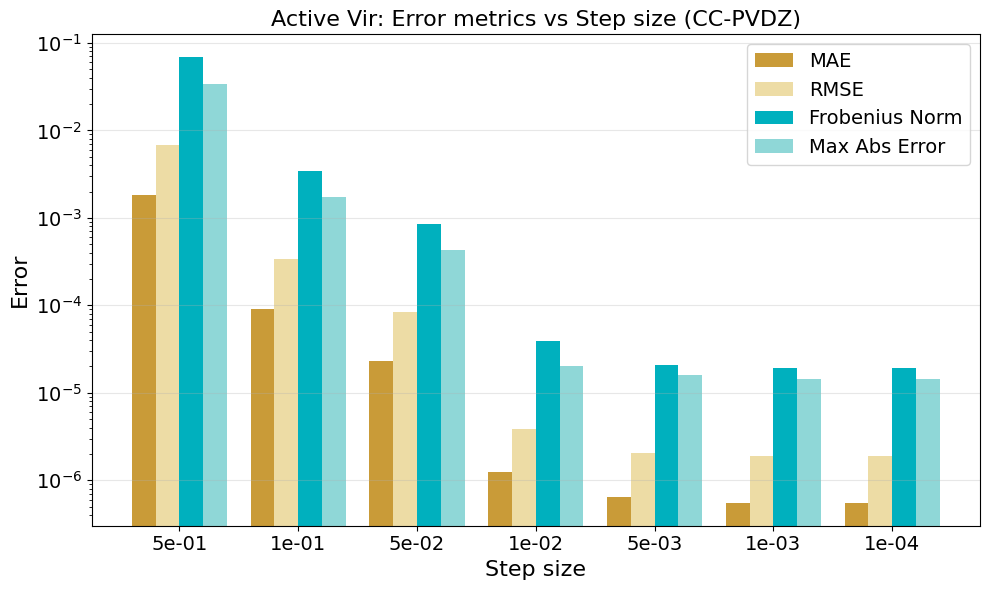

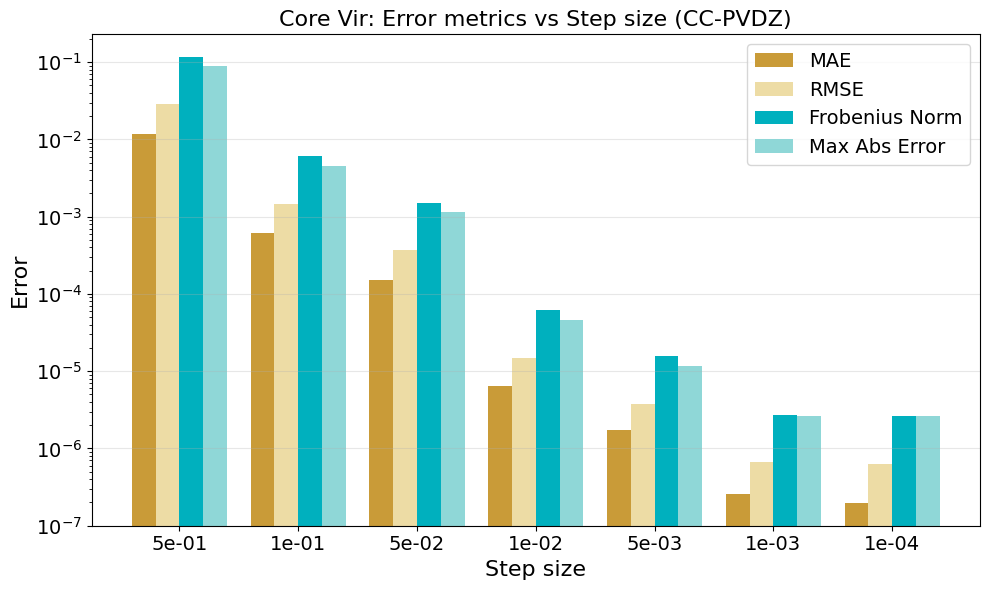

In [45]:
basis = 'CC-PVDZ'
with open(f'beh2.{basis}.json', 'r') as f:
    data = json.load(f)

barcolorset = {
'set1':["#0000a2", "#e9c716", "#bc272d", "#50ad9f"],
'set2':["#4a2377", "#f55f74", "#8cc5e3", "#0d7d87"],
'set3':["#d31f11", "#f47a00", "#62c8d3", "#007191"],
'set4':["#3594cc", "#8cc5e3", "#ea801c", "#f0b077"],
'set5':["#c99b38", "#eddca5", "#00b0be", "#8fd7d7"],
'set6':["#0d7d87", "#99c6cc", "#c31e23", "#ff5a5e"]
}

step_sizes = np.array([5e-1, 1e-1, 5e-2, 1e-2, 5e-3, 1e-3])
step_sizes = data['step_sizes']
metric_names = ["MAE", "RMSE", "Frobenius Norm", "Max Abs Error"]
block_names = ["core_active", "active_vir", "core_vir"]

# Create one grouped bar plot per block
saved_files = []
x = np.arange(len(step_sizes))
width = 0.2

for block in block_names:
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, metric in enumerate(metric_names):
        ax.bar(x + (i - 1.5) * width, data[block][metric], width=width, label=metric, color=list(barcolorset['set5'])[i])

    ax.set_xticks(x)
    ax.set_xticklabels([f"{h:.0e}" for h in step_sizes], fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlabel("Step size", fontsize=16)
    ax.set_ylabel("Error", fontsize=16)
    ax.set_yscale("log")
    ax.set_title(f"{block.replace('_', ' ').title()}: Error metrics vs Step size ({(basis)})", fontsize=16)
    ax.legend(fontsize=14)
    ax.grid(True, axis='y', alpha=0.3)

    out = f"BeH2_{basis}_{block}_grouped_bar.pdf"
    fig.tight_layout()
    fig.savefig(out, dpi=400, bbox_inches="tight")
    saved_files.append(out)
    # plt.close(fig)

print("\n".join(saved_files))

## k-RHF Orbital Gradient 

In [144]:

import os
import numpy as np
from ase import Atoms
from pyscf import lib
from pyscf.pbc import scf, df
from pyscf.pbc import gto as pgto

def make_h2_1D(intraH=1.0, interH=1.5, nx=1, vacuum=17.5):
    Lx = nx * (intraH + interH)
    cell = np.diag([Lx, vacuum, vacuum])
    y0 = vacuum / 2.0
    z0 = vacuum / 2.0
    positions = []
    symbols = []
    for i in range(nx):
        x0 = i * (intraH + interH)
        positions.append([x0,        y0, z0])   # H1
        positions.append([x0+intraH, y0, z0])   # H2
        symbols += ['N', 'N']
    atoms = Atoms(symbols=symbols, positions=positions, cell=cell, )
    atoms.center()
    return atoms


# H2 Molecule in 1D
atoms1D = make_h2_1D(intraH=0.74, interH=1.5, nx = 1, vacuum=17.5)
cell = pgto.Cell()
cell.a = atoms1D.cell.array
pos = atoms1D.get_positions()
sym = atoms1D.get_chemical_symbols()
cell.atom = [(sym[i], tuple(pos[i])) for i in range(len(sym))]
cell.basis = 'STO-6G'
cell.unit = 'Angstrom'
cell.max_memory = 100000
cell.ke_cutoff = 100
cell.precision = 1e-10
cell.verbose = 0 #lib.logger.INFO
# cell.output = 'h2_1D_CASCI.log'
cell.build()

nkpts = 2
kmesh1D = [nkpts, 1, 1]

kpts = cell.make_kpts(kmesh1D, wrap_around=True)

kmf = scf.KRHF(cell, kpts=kpts).density_fit(auxbasis='def2-svp-jkfit')
kmf.max_cycle=1000
kmf.exxdiv = None
kmf.conv_tol = 1e-6
kmf.kernel()

energy_nuc = kmf.energy_nuc()

In [145]:
# Analytical gradient
nocc = np.sum(kmf.mo_occ[0] > 0)
nvir = kmf.mo_coeff[0].shape[1] - nocc

grad_analyticals = kmf.get_grad(kmf.mo_coeff, kmf.mo_occ).reshape(nkpts, -1)
grad_analyticals = [grad_analytical.reshape(nvir, nocc).T 
                    for grad_analytical in grad_analyticals]

print(grad_analyticals[0].shape)
print(grad_analyticals[0].dtype)
print(grad_analyticals[0])
print("Max:", np.max(np.abs(grad_analyticals[0])))

(7, 3)
complex128
[[ 0.        +0.j -0.        +0.j -0.        +0.j]
 [-0.        -0.j  0.        +0.j  0.00000015+0.j]
 [-0.        +0.j  0.        +0.j -0.        +0.j]
 [-0.        -0.j  0.        -0.j  0.        +0.j]
 [ 0.        +0.j  0.        -0.j -0.        -0.j]
 [-0.        +0.j  0.        +0.j  0.        +0.j]
 [-0.        -0.j  0.        +0.j -0.00000007-0.j]]
Max: 1.5032085556275402e-07


In [148]:
from scipy.linalg import expm
np.set_printoptions(precision=8, suppress=True, linewidth=180)

def rotate_mos(mo_coeff, i, a, step, kidx):
    '''
    Rotate MOs by exponentiating an antisymmetric generator K.
    For a given occ and virtual orbital, and step size I will 
    have a rotation matrix which will update the mo_coeff.
    '''
    assert kidx <= len(mo_coeff)
    nmo = mo_coeff[0].shape[1]
    # Generating the antisymmetric generator K for the (i,a) pair
    kappa = np.zeros((nmo, nmo), dtype=mo_coeff[0].dtype)
    initval = 1.0 + 1j
    kappa[i, a] = initval
    kappa[a, i] = -initval.conjugate()
    U = expm(step * kappa)
    mo_coeff[kidx] = mo_coeff[kidx] @ U
    return mo_coeff

def compute_energy_at_mo(kmf, mo_rot):
    '''
    Given a rotated full MO coefficient matrix mo_rot, build the RHF density
    from the occupied columns and evaluate the HF total energy functional.
    '''
    nkpts = len(mo_rot)
    mo_occ = [mo_rot[k][:, np.where(kmf.mo_occ[k] > 0)[0]] 
              for k in range(nkpts)]
    dm = ([2.0 * mo_occ[k] @ mo_occ[k].conj().T 
                    for k in range(nkpts)])
    e_nuc = energy_nuc
    return kmf.energy_elec(dm_kpts=dm)[0] + e_nuc

def compute_grad_ia_numerical(mf, i, a, h, kidx):
    '''
    For a given occupied index iocc and virtual index avir, compute the orbital gradient using 
    central finite difference formula.
    '''
    mo_p = [c.copy() for c in mo_ref]
    mo_m = [c.copy() for c in mo_ref]

    mo_p = rotate_mos(mo_p, i, a,  h, kidx)
    mo_m = rotate_mos(mo_m, i, a, -h, kidx)

    e_p = compute_energy_at_mo(mf, mo_p)
    e_m = compute_energy_at_mo(mf, mo_m)

    grad_ia = (e_p - e_m) / (2.0 * h)
    return grad_ia

def compute_grad_mat_step_sizes(mf, step_sizes):
    
    mo_occ = mf.mo_occ[0]
    occidx = np.where(mo_occ > 0)[0]
    viridx = np.where(mo_occ == 0)[0]
    nocc = len(occidx)
    nvir = len(viridx)
    grad_mat = {}


    def get_grad_mat(h):
        GTot = np.empty((nkpts, nocc, nvir), dtype=mf.mo_coeff[0].dtype)
        for kidx in range(nkpts):
            G = np.zeros((nocc, nvir), dtype=mf.mo_coeff[0].dtype)
            for i_idx, iocc in enumerate(occidx):
                for a_idx, avir in enumerate(viridx):
                    g_fd = compute_grad_ia_numerical(mf, iocc, avir, h, kidx)
                    G[i_idx, a_idx] = g_fd
            GTot[kidx] = G
        return GTot
    
    for h in step_sizes:
        print(f"\n========== Step size h = {h:.1e} ==========", flush=True)
        grad_mat[h] = get_grad_mat(h)
    
    return grad_mat

# It's time to run and compare.

# Some sanity prints
mo_ref = kmf.mo_coeff.copy()
occidx = np.where(kmf.mo_occ[0] > 0)[0]
viridx = np.where(kmf.mo_occ[0] == 0)[0]
nocc = len(occidx)
nvir = len(viridx)

print(f"nkpts = {nkpts}")
print(f"nmo  = {kmf.mo_coeff[0].shape[1]}")
print(f"nocc = {nocc}")
print(f"nvir = {nvir}")

print(f"Analytic gradient matrix:", np.array(grad_analyticals).shape)

# Using finite difference compute the orbital gradient matrix for different step sizes
step_sizes = [5e-1, 1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 1e-4]
grad_mat_fd = compute_grad_mat_step_sizes(kmf, step_sizes)

errors_metrics = {}
grad_an = np.asarray(grad_analyticals)  # shape: (nkpts, nocc, nvir)

for h in step_sizes:
    grad_num = grad_mat_fd[h]
    grad_num = grad_num.ravel()
    grad_an = grad_an.ravel()
    diff = (grad_num - grad_an)
    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(np.abs(diff) ** 2))
    frobenius_norm = np.linalg.norm(diff)
    max_abs_error = np.max(np.abs(diff))

    errors_metrics[h] = {
        "mae": mae,
        "rmse": rmse,
        "frobenius_norm": frobenius_norm,
        "max_abs_error": max_abs_error,
    }

errors_metrics


nkpts = 2
nmo  = 10
nocc = 7
nvir = 3
Analytic gradient matrix: (2, 7, 3)

========== Step size h = 5.0e-01 ==========



========== Step size h = 1.0e-01 ==========

========== Step size h = 5.0e-02 ==========

========== Step size h = 1.0e-02 ==========

========== Step size h = 5.0e-03 ==========

========== Step size h = 1.0e-03 ==========

========== Step size h = 1.0e-04 ==========


{0.5: {'mae': 0.0015218994478925704,
  'rmse': 0.005769794315452997,
  'frobenius_norm': 0.03739254084159855,
  'max_abs_error': 0.03052231616864382},
 0.1: {'mae': 0.00010122721573318369,
  'rmse': 0.00038373939491151307,
  'frobenius_norm': 0.002486915514185449,
  'max_abs_error': 0.0020296275719299864},
 0.05: {'mae': 2.570233057225618e-05,
  'rmse': 9.740959177721464e-05,
  'frobenius_norm': 0.0006312863058458905,
  'max_abs_error': 0.0005149186566921251},
 0.01: {'mae': 1.0486000223953578e-06,
  'rmse': 3.94808475885812e-06,
  'frobenius_norm': 2.55865135774956e-05,
  'max_abs_error': 2.0469372899960805e-05},
 0.005: {'mae': 2.743466385628979e-07,
  'rmse': 1.0298989324377314e-06,
  'frobenius_norm': 6.674507926696013e-06,
  'max_abs_error': 4.9411094248988285e-06},
 0.001: {'mae': 4.2760632071307095e-08,
  'rmse': 2.272689603618932e-07,
  'frobenius_norm': 1.472871200902164e-06,
  'max_abs_error': 1.4550842037979133e-06},
 0.0001: {'mae': 4.8499449103263716e-08,
  'rmse': 2.18914

In [149]:
import json
with open('n2_krhf_nk2.json', 'w') as f:
    json.dump(errors_metrics, f, indent=2)

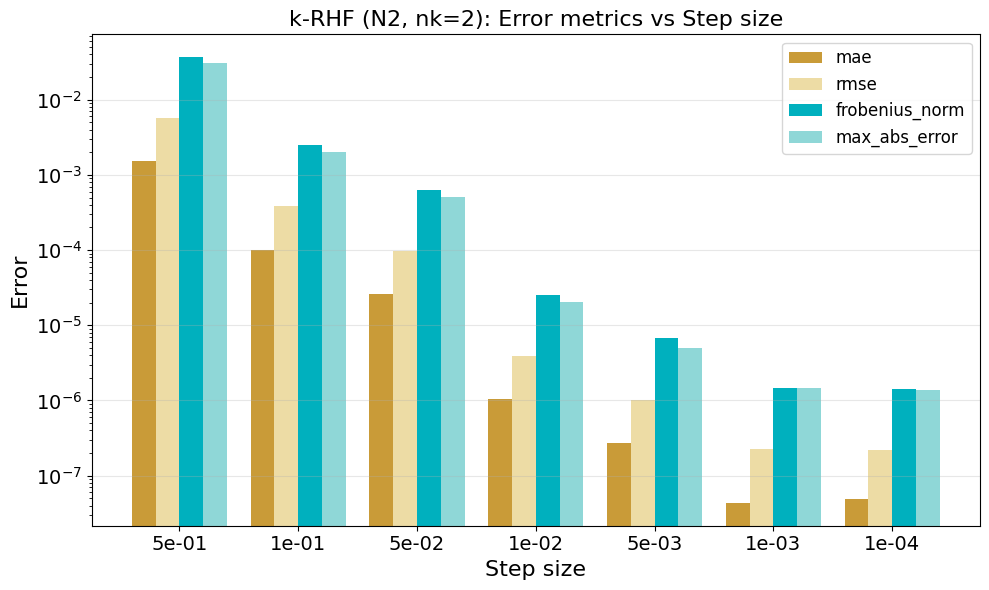

In [155]:
with open("n2_krhf_nk2.json", "r") as f:
    data = json.load(f)

barcolorset = {
    "set1": ["#0000a2", "#e9c716", "#bc272d", "#50ad9f"],
    "set2": ["#4a2377", "#f55f74", "#8cc5e3", "#0d7d87"],
    "set3": ["#d31f11", "#f47a00", "#62c8d3", "#007191"],
    "set4": ["#3594cc", "#8cc5e3", "#ea801c", "#f0b077"],
    "set5": ["#c99b38", "#eddca5", "#00b0be", "#8fd7d7"],
    "set6": ["#0d7d87", "#99c6cc", "#c31e23", "#ff5a5e"],
}

# Sort by numerical step size (largest to smallest)
items = sorted(data.items(), key=lambda kv: float(kv[0]), reverse=True)
step_labels = [k for k, _ in items]
x = np.arange(len(step_labels))

metric_names = ["mae", "rmse", "frobenius_norm", "max_abs_error"]
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
for i, metric in enumerate(metric_names):
    y = [v[metric] for _, v in items]
    ax.bar(
        x + (i - 1.5) * width,
        y,
        width=width,
        label=metric,
        color=barcolorset["set5"][i],
    )

ax.set_xticks(x)
ax.set_xticklabels([f"{float(h):.0e}" for h in step_labels], fontsize=14)
ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel("Step size", fontsize=16)
ax.set_ylabel("Error", fontsize=16)
ax.set_yscale("log")
ax.set_title("k-RHF (N2, nk=2): Error metrics vs Step size", fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

## k-CASSCF Gradient Comparison

In [ ]:
grad_ana = np.array([-3.55271364e-09-5.76702888e-18j, -3.26798499e-03-2.48689957e-08j,
        5.15541210e-03+1.02140518e-07j,  2.17134911e-17+2.66453531e-09j,
        1.77635684e-09-2.46519033e-26j, -8.88178420e-10-3.55271368e-09j,
       -8.88178420e-10+8.88178420e-10j, -8.88178420e-10+4.44089210e-09j,
       -4.97434716e-03-2.35433895e-04j,  8.88178420e-10+8.88178420e-10j,
        1.77635684e-09+2.21867130e-25j,  7.39557099e-26+1.77635684e-09j,
        2.46519033e-25+8.88178420e-10j,  0.00000000e+00-1.77635684e-09j,
       -1.77635684e-09+8.88178420e-10j, -2.36428477e-03-2.61840327e-04j,
        1.10348078e-18-5.43728590e-18j, -3.13032792e-20+1.77635684e-09j,
        5.38213710e-19-8.88178422e-10j,  8.88178420e-10+8.88178420e-10j,
        8.88178268e-10-8.88178406e-10j,  2.45053755e-04+2.71391798e-05j,
        2.35333358e-19+8.88178419e-10j, -5.67837075e-20+8.88178420e-10j,
       -2.25280774e-18+1.09672728e-17j,  8.88178420e-10+8.88178416e-10j,
        1.50639501e-04+7.13207271e-06j, -7.10542604e-09-3.55271369e-09j])
grad_ana.shape

grad_num = np.array([-2.66453441e-09+2.66453526e-09j, -2.16279172e-03+6.16946494e-05j,
        1.38961971e-02-1.35003120e-07j,  1.77635648e-09+3.55271371e-09j,
       -8.88178420e-10+8.88178420e-10j, -8.88178420e-10+9.86076132e-26j,
        7.43918172e-03+1.75163883e-04j, -1.23259516e-25+8.88178420e-10j,
       -8.88178420e-10+1.77635684e-09j,  8.88178420e-10+8.88178420e-10j,
       -2.66453526e-09-9.86076132e-26j,  0.00000000e+00-8.88178420e-10j,
       -1.10933565e-25-2.46519033e-26j, -8.88178420e-10-1.77635684e-09j,
        1.77635684e-09+2.66453526e-09j,  7.51558815e-05-3.59356989e-05j,
       -2.19203932e-19-8.88178415e-10j,  8.88178419e-10+5.52184287e-19j,
       -4.83571079e-16+2.66453527e-09j,  1.40704790e-19+5.35614471e-19j,
        2.89422404e-19-5.57617028e-18j, -2.67700528e-04+1.37507783e-04j,
       -3.32830564e-19+8.88178427e-10j,  8.88178420e-10+8.88178420e-10j,
       -1.85469418e-05-4.33431069e-07j, -8.88178421e-10-3.54160085e-18j,
       -6.85546595e-19+1.29256537e-17j,  8.88176197e-10-2.66453393e-09j])
grad_num.shape

(28,)

In [162]:
grad_num .real/ grad_ana.real

/tmp/ipykernel_1615055/3703892995.py:1: RuntimeWarning: divide by zero encountered in divide
  grad_num .real/ grad_ana.real


array([ 7.49999769e-01,  6.61812012e-01,  2.69545806e+00,  8.18088842e+07, -5.00000000e-01,  1.00000000e+00, -8.37577400e+06,  1.38777878e-16,  1.78551756e-07,  1.00000000e+00,
       -1.50000000e+00,  0.00000000e+00, -4.50000001e-01,            -inf, -1.00000000e+00, -3.17879988e-02, -1.98647712e-01, -2.83733347e+10, -8.98474101e+02,  1.58419510e-10,
        3.25860713e-10, -1.09241553e+00, -1.41429403e+00, -1.56414306e+10,  8.23281165e+12, -1.00000000e+00, -4.55090856e-15, -1.24999710e-01])